<a href="https://colab.research.google.com/github/AbhinavKumar0000/Machine_learning/blob/main/Fine_Tunning_DistilBERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers datasets pandas torch scikit-learn accelerate sentencepiece

In [ ]:
!pip install evaluate

In [ ]:
!pip install --upgrade transformers accelerate

In [ ]:
import pandas as pd
from datasets import Dataset
import evaluate
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np
import torch
import os

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.8.0+cu126
CUDA available: True


In [ ]:
DATASET_FILE = "/content/processed_prompt_dataset_v3.csv"
df = pd.read_csv(DATASET_FILE)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2933 entries, 0 to 2932
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   prompt    2933 non-null   object 
 1   category  2933 non-null   object 
 2   score     2933 non-null   float64
dtypes: float64(1), object(2)
memory usage: 68.9+ KB


In [ ]:
# --- Configuration ---
MODEL_NAME = "distilbert-base-uncased"
OUTPUT_DIR = "./prompt_scorer_model_final"

# --- Load Data ---
print(f"Loading dataset from {DATASET_FILE}...")
try:
    df = pd.read_csv(DATASET_FILE)
except FileNotFoundError:
    print(f"Error: {DATASET_FILE} not found.")
    print("Please make sure your 'prompt_dataset.csv' is in the same directory as this notebook.")
else:
    print(f"Loaded {len(df)} rows.")

    df['score'] = df['score'].astype(float)

    df_train, df_val = train_test_split(df, test_size=0.1, random_state=42)

    train_dataset = Dataset.from_pandas(df_train.reset_index(drop=True))
    val_dataset = Dataset.from_pandas(df_val.reset_index(drop=True))

    print(f"Data split: {len(train_dataset)} training, {len(val_dataset)} validation.")
    print("\nExample data point:")
    print(train_dataset[0])

Loading dataset from /content/processed_prompt_dataset_v3.csv...
Loaded 2933 rows.
Data split: 2639 training, 294 validation.

Example data point:
{'prompt': 'Write a fantasy adventure story about a lonely robot in a small village. Write it end with a twist.', 'category': 'AI Digital Storytelling/Writing', 'score': 100.0}


In [ ]:
# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=1)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
def tokenize_function(examples):
    formatted_inputs = [f"[CAT] {cat} [SEP] {p}" for cat, p in zip(examples['category'], examples['prompt'])]
    return tokenizer(formatted_inputs, padding="max_length", truncation=True)

print("Tokenizing datasets...")
tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_val_dataset = val_dataset.map(tokenize_function, batched=True)

tokenized_train_dataset = tokenized_train_dataset.rename_column("score", "labels")
tokenized_val_dataset = tokenized_val_dataset.rename_column("score", "labels")

tokenized_train_dataset = tokenized_train_dataset.remove_columns(['prompt', 'category'])
tokenized_val_dataset = tokenized_val_dataset.remove_columns(['prompt', 'category'])

print("Tokenization complete.")
print("Example of a tokenized datapoint:")
print(tokenized_train_dataset[0])

Tokenizing datasets...


Map:   0%|          | 0/2639 [00:00<?, ? examples/s]

Map:   0%|          | 0/294 [00:00<?, ? examples/s]

Tokenization complete.
Example of a tokenized datapoint:
{'labels': 100.0, 'input_ids': [101, 1031, 4937, 1033, 9932, 3617, 20957, 1013, 3015, 102, 4339, 1037, 5913, 6172, 2466, 2055, 1037, 9479, 8957, 1999, 1037, 2235, 2352, 1012, 4339, 2009, 2203, 2007, 1037, 9792, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [ ]:
import evaluate

mse_metric = evaluate.load("mse")
mae_metric = evaluate.load("mae")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = predictions.flatten()

    mse = mse_metric.compute(predictions=predictions, references=labels)
    mae = mae_metric.compute(predictions=predictions, references=labels)

    return {
        "mse": mse["mse"],
        "mae": mae["mae"],
    }

In [ ]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=100,
    report_to="none",
)

# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_val_dataset,
    compute_metrics=compute_metrics,
)

# Start training!
print("--- Starting Model Training (Compatibility Mode) ---")
trainer.train()
print("--- Training Complete ---")

--- Starting Model Training (Compatibility Mode) ---


Step,Training Loss
100,1410.921700
200,946.087300
300,399.748400
400,96.437300
500,59.435700
600,43.605800
700,34.754600
800,20.705500


KeyboardInterrupt: 

In [ ]:
print("--- Evaluating Final Model ---")
eval_results = trainer.evaluate()

print(f"\nFinal Model Performance (on validation set):")
print(f"  Mean Squared Error (MSE): {eval_results['eval_mse']:.4f}")
print(f"  Mean Absolute Error (MAE): {eval_results['eval_mae']:.4f}")
print(f"  (This means your model's predictions are, on average, off by ~{eval_results['eval_mae']:.2f} points)")

print(f"\nSaving best model and tokenizer to {OUTPUT_DIR}...")
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print("--- All Done! ---")

--- Evaluating Final Model ---



Final Model Performance (on validation set):
  Mean Squared Error (MSE): 15.0370
  Mean Absolute Error (MAE): 1.9494
  (This means your model's predictions are, on average, off by ~1.95 points)

Saving best model and tokenizer to ./prompt_scorer_model_final...
--- All Done! ---


--- Score Statistics ---
count    2933.000000
mean       68.938629
std        36.801368
min         2.000000
25%        15.000000
50%        90.000000
75%        96.000000
max       100.000000
Name: score, dtype: float64

--- Score Distribution ---


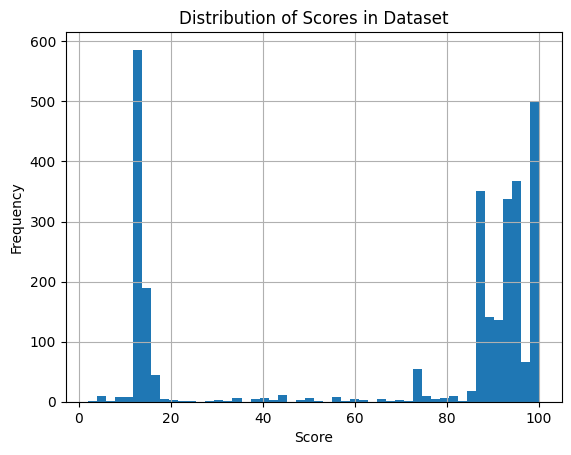

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/processed_prompt_dataset_v3.csv")

print("--- Score Statistics ---")
print(df['score'].describe())

print("\n--- Score Distribution ---")
df['score'].hist(bins=50)
plt.title('Distribution of Scores in Dataset')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

In [ ]:
import torch
from transformers import pipeline
import warnings
import os

MODEL_PATH = "./prompt_scorer_model_final"
CATEGORIES = [
    "Meme Generation",
    "AI Visual Art Creation",
    "AI Digital Storytelling/Writing",
    "AI Song Factory",
    "AI-Generated Poetry in Local Languages"
]

def load_model():
    """Loads the fine-tuned pipeline from disk."""
    print(f"Loading model from {MODEL_PATH}...")

    # Check if model path exists
    if not os.path.exists(MODEL_PATH):
        print(f"Error: Model directory not found at {MODEL_PATH}")
        print("Please run the 'train_model.ipynb' notebook first to train and save the model.")
        return None

    # Suppress unnecessary warnings
    warnings.filterwarnings("ignore", "Using a pipeline without a model_max_length.*")

    # Check for GPU
    device = 0 if torch.cuda.is_available() else -1
    device_name = "GPU" if device == 0 else "CPU"
    print(f"Running on: {device_name}")

    # Load the "text-classification" pipeline. It automatically detects
    # regression models if they were saved with num_labels=1.
    try:
        scorer_pipeline = pipeline("text-classification", model=MODEL_PATH, device=device)
    except Exception as e:
        print(f"Error loading model: {e}")
        return None

    print("Model loaded successfully.\n")
    return scorer_pipeline

def get_user_input():
    """Gets category and prompt from the user."""
    print("Please select a category:")
    for i, category in enumerate(CATEGORIES, 1):
        print(f"  {i}. {category}")

    # Get category choice
    while True:
        try:
            choice_str = input(f"\nEnter number (1-{len(CATEGORIES)}): ")
            choice = int(choice_str)
            if 1 <= choice <= len(CATEGORIES):
                category = CATEGORIES[choice - 1]
                break
            else:
                print("Invalid choice. Please enter a number from the list.")
        except ValueError:
            print("Invalid input. Please enter a number.")

    # Get prompt text
    prompt_text = input("Enter your prompt: ")

    return category, prompt_text

def format_input(category, prompt_text):
    """
    Formats the input for the model.
    *** This MUST match the format used during training. ***
    """
    return f"[CAT] {category} [SEP] {prompt_text}"

def main():
    scorer = load_model()
    if scorer is None:
        return # Exit if model failed to load

    while True:
        category, prompt_text = get_user_input()

        # Format the input as the model expects
        formatted_input = format_input(category, prompt_text)

        print("\nScoring...")

        # Run the prediction
        result = scorer(formatted_input)

        # The pipeline returns a list with a dict. The 'score' key holds our value.
        predicted_score = result[0]['score']

        print("---")
        print(f"Category: {category}")
        print(f"Prompt: {prompt_text}")
        print(f"** Predicted Score: {predicted_score:.2f} / 100 **")
        print("---\n")

        # Ask to continue
        if input("Score another prompt? (y/n): ").lower().strip() != 'y':
            break

    print("Exiting.")

if __name__ == "__main__":
    main()

Device set to use cuda:0


Loading model from ./prompt_scorer_model_final...
Running on: GPU
Model loaded successfully.

Please select a category:
  1. Meme Generation
  2. AI Visual Art Creation
  3. AI Digital Storytelling/Writing
  4. AI Song Factory
  5. AI-Generated Poetry in Local Languages

Enter number (1-5): 1
Enter your prompt: meme

Scoring...
---
Category: Meme Generation
Prompt: meme
** Predicted Score: 11.21 / 100 **
---

Score another prompt? (y/n): y
Please select a category:
  1. Meme Generation
  2. AI Visual Art Creation
  3. AI Digital Storytelling/Writing
  4. AI Song Factory
  5. AI-Generated Poetry in Local Languages

Enter number (1-5): 1
Enter your prompt: create a meme i ishowspeed trynot to laugh with chinese voice in backround

Scoring...
---
Category: Meme Generation
Prompt: create a meme i ishowspeed trynot to laugh with chinese voice in backround
** Predicted Score: 88.36 / 100 **
---

Score another prompt? (y/n): y
Please select a category:
  1. Meme Generation
  2. AI Visual Art 